This notebook is used for:
- reproducing the results of Harman WRR 2024;
- and training differentiable SAS-based transport model.

In [1]:
import pandas as pd

import jax
import jax.numpy as jnp
import jax.tree_util as jtu

import equinox as eqx

import optax

from DiffFlowTransport import SASTransport
from DiffFlowTransport.sas import SAS_Gamma, SAS_Uniform, SAS_MDN, SAS_Gamma_VaryingScale
from DiffFlowTransport.utils import compute_metrics, train, mse

import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2
# %reload_ext autoreload


# Read the data

In [2]:
df = pd.read_csv('./data.csv', index_col=1)
df.index = pd.to_datetime(df.index, format='%m/%d/%y')
df.head()

,timestep,J,Cl mg/l,Q,ET,Q Cl mg/l,S_scale
datetime,,,,,,,
1983-05-03,0,0.25,1.643836,3.404765,3.279204,NaN,4675.943543
1983-05-04,1,0.00,0.000000,3.032749,2.572585,NaN,4909.717786
1983-05-05,2,6.25,1.643836,2.954061,0.882162,NaN,4979.097380
1983-05-06,3,11.75,1.643836,3.821581,1.653902,NaN,4471.583891
1983-05-07,4,11.25,1.643836,5.064662,0.994315,NaN,3957.744963


In [3]:
J = jnp.array(df['J'].values)
Q = jnp.array(df['Q'].values)
ET = jnp.array(df['ET'].values)
C_J = jnp.array(df['Cl mg/l'].values)
C_Q_J = jnp.array(df['Q Cl mg/l'].values)

In [4]:
# import jax
# import jax.numpy as jnp
# jax.scipy.stats.uniform.cdf(1.1, scale=2.2)

# Running the SAS model (w/o training)

In [5]:
# Parameters
params = {
    "dt": 1.,
    "α_Q": 1.,
    "α_ET": 0.,
    "k1": [0.],
    "C_eq": [0.],
    # "C_Q_old": [0.],
    # "C_Q_old": [jnp.mean(C_J * J) / Q.mean() / (1-0.26)]
    "C_Q_old": [jnp.mean(C_J * J) / Q.mean()]
}

# Other arguments for running the model
nt = Q.size
sTmT_init = jnp.zeros([nt, 2])


## Invariant SAS functions
Assuming $\Omega_Q$ and $\Omega_{ET}$ are the gamma and uniform distributions, separately.

In [32]:
# SAS functions
sas_Q = SAS_Gamma(a=0.53, scale=8215.)
sas_ET = SAS_Uniform(scale=737.)

# SAS arguments 
sas_Q_args = Q[:,None]
sas_ET_args = ET[:,None]


In [33]:
# Initialize the SAS transport model
sas_transport = SASTransport(sas_Q, sas_ET, **params)

In [34]:
# Run the model
sT, mT, mQETs, pQETs, mRs, C_Q = sas_transport(
    J, C_J, Q, ET, sTmT_init, sas_Q_args, sas_ET_args
)
# plt.plot(C_Q)
df['C_Q 1'] = C_Q


In [35]:
sTmT_init2 = jnp.concat([sT[:,-1,None], mT[:,-1,:]], axis=-1)
# Run the model
sT, mT, mQETs, pQETs, mRs, C_Q = sas_transport(
    J, C_J, Q, ET, sTmT_init2, sas_Q_args, sas_ET_args
)
df['C_Q 1b'] = C_Q

In [51]:
# Compute the metrics
compute_metrics(df['C_Q 1b'].values, df['Q Cl mg/l'].values, mask_naninf=True)


{'rse': 0.5840387536707714,
 'mare': 0.09473395073343857,
 'rmse': 0.9173510813452572,
 'mse': 0.8415330064453127,
 'r2': -0.23362611619889395,
 'kge': 0.5612421264030389,
 'nse': 0.4159612463292286,
 'mkge': 0.5403060392298826,
 'cc': 0.6945599824579526,
 'alpha': 1.0437154971450202,
 'beta': 0.6592451195334164}

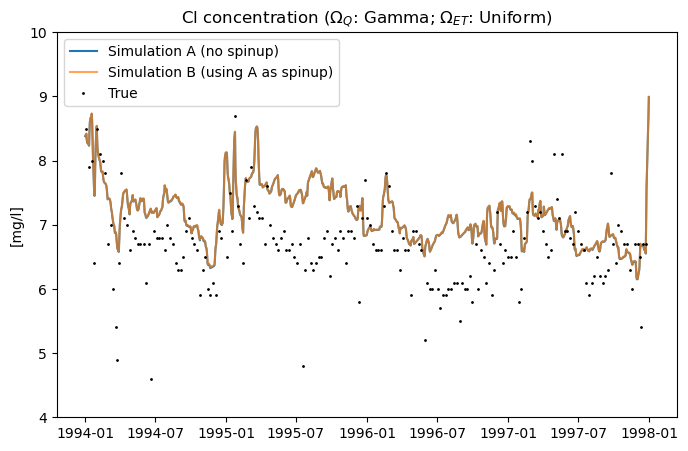

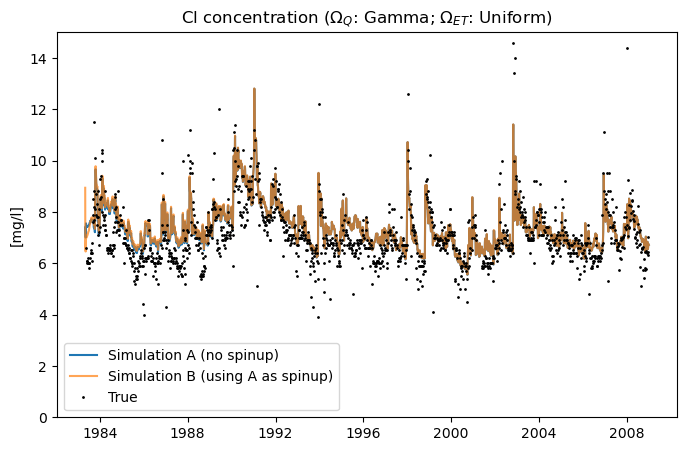

In [36]:
fig, ax = plt.subplots(1, 1, figsize=(8,5))
ax.plot(df['C_Q 1']["1994":"1997"], label='Simulation A (no spinup)')
ax.plot(df['C_Q 1b']["1994":"1997"], alpha=0.7, label='Simulation B (using A as spinup)')
ax.plot(df['Q Cl mg/l']["1994":"1997"], 'k.', markersize=2, label='True')
ax.set(ylim=[4, 10], title='Cl concentration ($\Omega_Q$: Gamma; $\Omega_{ET}$: Uniform)', 
       ylabel='[mg/l]')
ax.legend()

fig, ax = plt.subplots(1, 1, figsize=(8,5))
ax.plot(df['C_Q 1'], label='Simulation A (no spinup)')
ax.plot(df['C_Q 1b'], alpha=0.7, label='Simulation B (using A as spinup)')
ax.plot(df['Q Cl mg/l'], 'k.', markersize=2, label='True')
ax.set(ylim=[0, 15], title='Cl concentration ($\Omega_Q$: Gamma; $\Omega_{ET}$: Uniform)', 
       ylabel='[mg/l]')
ax.legend()


## Storage dependent SAS

In [52]:
# SAS functions
sas_Q = SAS_Gamma_VaryingScale(a=0.69, scale=8215.)
sas_ET = SAS_Uniform(scale=398.)

# SAS arguments 
# sas_Q_args = jnp.array(df['S_scale'].values[:,None])
sas_Q_args = jnp.array(df['S_scale'].values)
sas_ET_args = ET


In [53]:
# Initialize the SAS transport model
sas_transport2 = SASTransport(sas_Q, sas_ET, **params)

In [56]:
# Run the model
sT, mT, mQETs, pQETs, mRs, C_Q = sas_transport2(
    J, C_J, Q, ET, sTmT_init, sas_Q_args, sas_ET_args
)
# plt.plot(C_Q)
df['C_Q 2'] = C_Q

In [57]:
# Rerun the model
sTmT_init2 = jnp.concat([sT[:,-1,None], mT[:,-1,:]], axis=-1)
sT, mT, mQETs, pQETs, mRs, C_Q = sas_transport2(
    J, C_J, Q, ET, sTmT_init2, sas_Q_args, sas_ET_args
)
df['C_Q 2b'] = C_Q

In [50]:
# Compute the metrics
compute_metrics(df['C_Q 2b'].values, df['Q Cl mg/l'].values, mask_naninf=True)


{'rse': 0.613047862332254,
 'mare': 0.10552430880638092,
 'rmse': 0.9398573360963965,
 'mse': 0.8833318122142149,
 'r2': -0.03498391778069565,
 'kge': 0.6401121940536874,
 'nse': 0.38695213766774605,
 'mkge': 0.6084366764541781,
 'cc': 0.7312276692176718,
 'alpha': 1.0648771552185825,
 'beta': 0.7227379844211821}

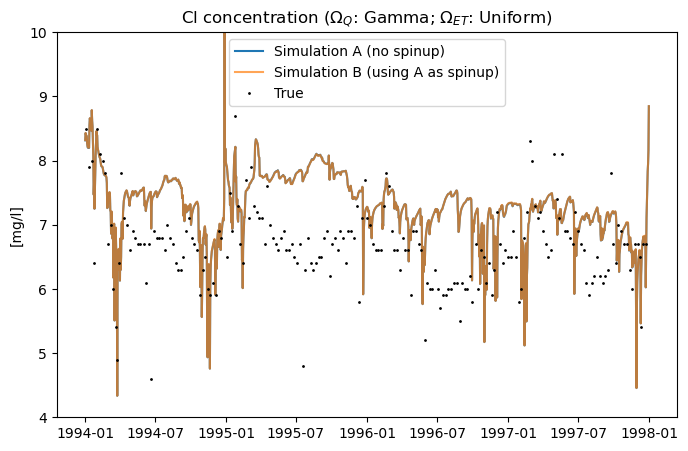

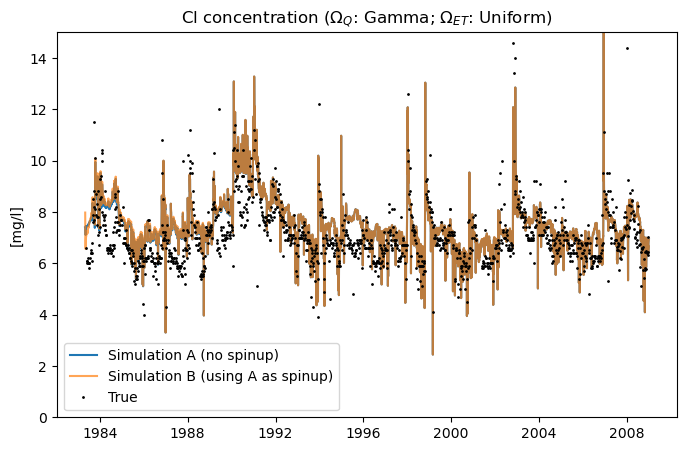

In [31]:
fig, ax = plt.subplots(1, 1, figsize=(8,5))
ax.plot(df['C_Q 2']["1994":"1997"], label='Simulation A (no spinup)')
ax.plot(df['C_Q 2b']["1994":"1997"], alpha=0.7, label='Simulation B (using A as spinup)')
ax.plot(df['Q Cl mg/l']["1994":"1997"], 'k.', markersize=2, label='True')
ax.set(ylim=[4, 10], title='Cl concentration ($\Omega_Q$: Gamma; $\Omega_{ET}$: Uniform)', 
       ylabel='[mg/l]')
ax.legend()


fig, ax = plt.subplots(1, 1, figsize=(8,5))
ax.plot(df['C_Q 2'], label='Simulation A (no spinup)')
ax.plot(df['C_Q 2b'], alpha=0.7, label='Simulation B (using A as spinup)')
ax.plot(df['Q Cl mg/l'], 'k.', markersize=2, label='True')
ax.set(ylim=[0, 15], title='Cl concentration ($\Omega_Q$: Gamma; $\Omega_{ET}$: Uniform)', 
       ylabel='[mg/l]')
ax.legend()


## MDN-based SAS

In [149]:
# SAS functions
n_input, n_hidden, n_mixture, key = 1, 20, 5, jax.random.key(42)
mlp_kwargs = {"width_size": 20, "depth":3}
sas_Q = SAS_MDN(n_input, n_hidden, n_mixture, key, scale=8215, **mlp_kwargs)
sas_ET = SAS_Uniform(scale=737.)

# SAS arguments 
sas_Q_args = Q[:,None]
sas_ET_args = ET[:,None]


In [66]:
# Initialize the SAS transport model
sas_transport2 = SASTransport(sas_Q, sas_ET, **params)

In [68]:
# Spinup the model
sT, mT, mQETs, pQETs, mRs, C_Q = sas_transport2(
    J, C_J, Q, ET, sTmT_init, sas_Q_args, sas_ET_args
)
# plt.plot(C_Q)
df['C_Q 2'] = C_Q

In [69]:
# Rerun the model
sTmT_init2 = jnp.concat([sT[:,-1,None], mT[:,-1,:]], axis=-1)
sT, mT, mQETs, pQETs, mRs, C_Q = sas_transport2(
    J, C_J, Q, ET, sTmT_init2, sas_Q_args, sas_ET_args
)
df['C_Q 2b'] = C_Q

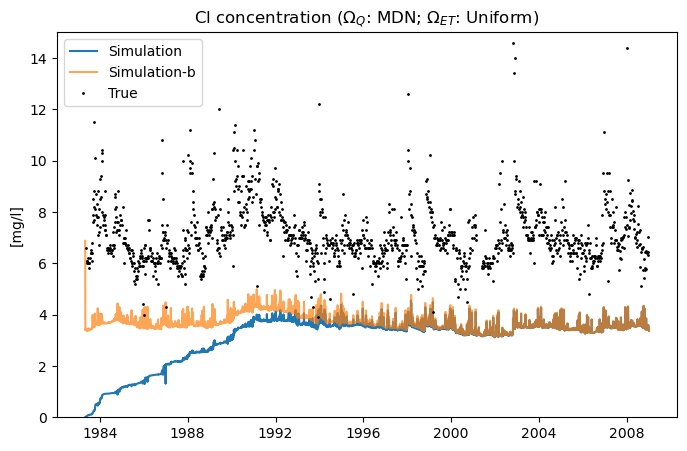

In [70]:
fig, ax = plt.subplots(1, 1, figsize=(8,5))
ax.plot(df['C_Q 2'], label='Simulation')
ax.plot(df['C_Q 2b'], alpha=0.7, label='Simulation-b')
ax.plot(df['Q Cl mg/l'], 'k.', markersize=2, label='True')
ax.set(ylim=[0, 15], title='Cl concentration ($\Omega_Q$: MDN; $\Omega_{ET}$: Uniform)', 
       ylabel='[mg/l]')
ax.legend()


# Training the SAS-based transport model

In [6]:
# Training parameters
epochs = 10
loss_func = mse
optim = optax.adam(learning_rate=0.01)

## Invariant SAS functions

In [7]:
# SAS functions
sas_Q = SAS_Gamma(a=0.53, scale=8215.)
sas_ET = SAS_Uniform(scale=737.)

# SAS arguments 
sas_Q_args = Q[:,None]
sas_ET_args = ET[:,None]

# Initialize the SAS transport model
model = SASTransport(sas_Q, sas_ET, **params)


In [8]:
filter_model_spec = jtu.tree_map(lambda _: False, model)
sas_Q_filter = jtu.tree_map(lambda _: True, sas_Q)
sas_ET_filter = jtu.tree_map(lambda _: True, sas_ET)
sas_Q_filter = eqx.tree_at(lambda t: (t.loc,), sas_Q_filter, replace=(False,))
sas_ET_filter = eqx.tree_at(lambda t: (t.loc,), sas_ET_filter, replace=(False,))
filter_model_spec = eqx.tree_at(lambda t: (t.sas_Q, t.sas_ET), filter_model_spec, replace=(sas_Q_filter, sas_ET_filter))


In [10]:
# Inputs and outputs
x = [J, C_J, Q, ET, sTmT_init, sas_Q_args, sas_ET_args]
y = C_Q_J

In [ ]:
model_new, loss_train, _ = train(
    model.get_CQ, filter_model_spec.get_CQ,
    epochs, loss_func, optim, x, y
)


 30%|███       | 3/10 [13:20<31:21, 268.83s/it]

## MDN-based SAS

In [ ]:
# SAS functions
n_input, n_hidden, n_mixture, key = 1, 20, 5, jax.random.key(42)
mlp_kwargs = {"width_size": 20, "depth":3}
sas_Q = SAS_MDN(n_input, n_hidden, n_mixture, key, scale=8215, **mlp_kwargs)
sas_ET = SAS_Uniform(scale=737.)

# SAS arguments 
sas_Q_args = Q[:,None]
sas_ET_args = ET[:,None]

# Initialize the SAS transport model
model_mdn = SASTransport(sas_Q, sas_ET, **params)


In [ ]:
filter_model_spec = jtu.tree_map(lambda _: False, model)
sas_Q_filter = jtu.tree_map(lambda _: True, sas_Q)
sas_ET_filter = jtu.tree_map(lambda _: True, sas_ET)
sas_Q_filter = eqx.tree_at(lambda t: (t.loc,), sas_Q_filter, replace=(False,))
sas_ET_filter = eqx.tree_at(lambda t: (t.loc,), sas_ET_filter, replace=(False,))
filter_model_spec = eqx.tree_at(lambda t: (t.sas_Q, t.sas_ET), filter_model_spec, replace=(sas_Q_filter, sas_ET_filter))


In [ ]:
# Inputs and outputs
x = [J, C_J, Q, ET, sTmT_init, sas_Q_args, sas_ET_args]
y = C_Q_J

model_mdn_new, loss_train, _ = train(
    model.get_CQ, filter_model_spec.get_CQ,
    epochs, loss_func, optim, x, y
)
